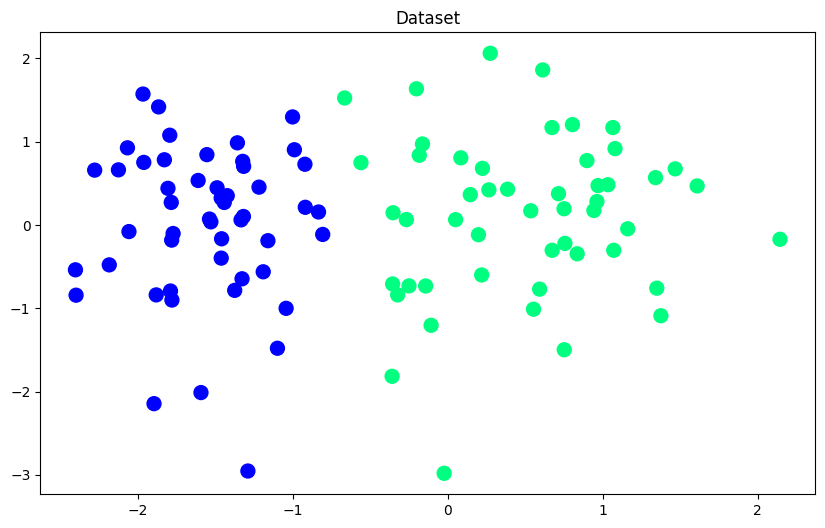

In [1]:


from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=10
)

# Visualize data
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.title("Dataset")
plt.show()

In [2]:
# Sigmoid fn.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [3]:
# LR using SGD from Scratch

def logistic_regression(X, y):

    X = np.insert(X, 0, 1, axis=1)   
    weights = np.ones(X.shape[1])

    lr = 0.1

    for i in range(1000):

        j = np.random.randint(0,100)

        z = np.dot(X[j], weights)
        y_hat = sigmoid(z)

        # Gradient Update
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

In [4]:
intercept_, coef_ = logistic_regression(X, y)

print("Coefficients:", coef_)
print("Intercept:", intercept_)

Coefficients: [4.51642692 0.07487571]
Intercept: 2.588866996457417


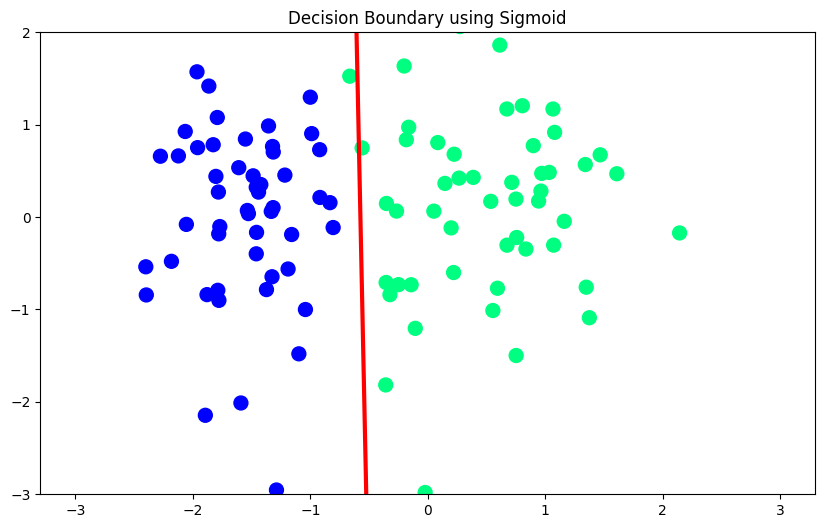

In [5]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)
plt.title("Decision Boundary using Sigmoid")
plt.show()

In [6]:
# Boundary Movement During Training

def logistic_boundary(X,y):

    m = []
    b = []

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])

    lr = 0.1

    for i in range(200):

        j = np.random.randint(0,100)

        z = np.dot(X[j], weights)
        y_hat = sigmoid(z)

        weights = weights + lr*(y[j]-y_hat)*X[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))

    return m,b

In [7]:
m,b = logistic_boundary(X,y)

print(m[:5])
print(b[:5])

[np.float64(-1.0479963680770414), np.float64(-1.216276195938867), np.float64(-1.1934639042134119), np.float64(-1.1807585298700736), np.float64(-1.3177969707554487)]
[np.float64(-0.9737947626687464), np.float64(-0.9766502446098313), np.float64(-0.9801134544929073), np.float64(-0.9831538323307685), np.float64(-0.974035081890442)]


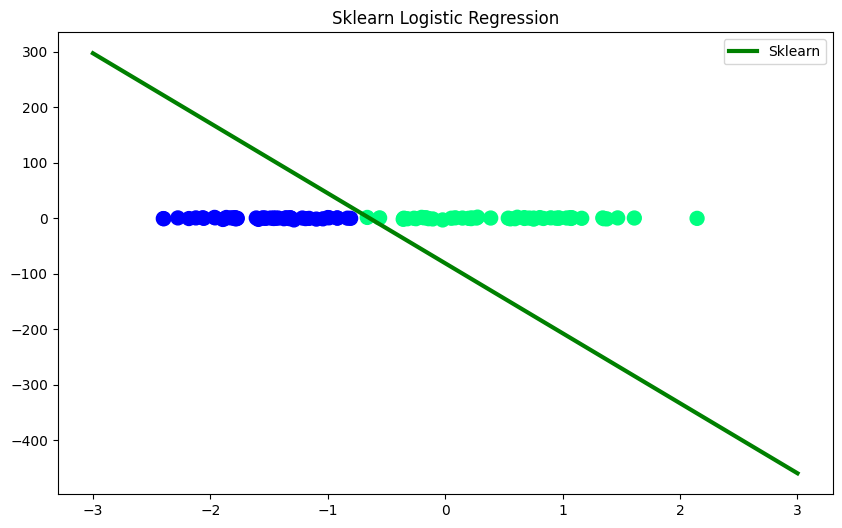

In [8]:
# Comparing with sklearn LogisticRegression

from sklearn.linear_model import LogisticRegression

lor = LogisticRegression()
lor.fit(X,y)

m = -(lor.coef_[0][0] / lor.coef_[0][1])
b = -(lor.intercept_[0] / lor.coef_[0][1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='green',linewidth=3,label='Sklearn')
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.legend()
plt.title("Sklearn Logistic Regression")
plt.show()